In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os
os.environ["PATH"] += ':/mnt/sw/nix/store/2h2mfxgy98zls6ja0czcz087i38v8wx3-texlive-20240312/bin/x86_64-linux'

import scienceplots
plt.style.use('science')
import importlib
import matplotlib.pyplot as plt

importlib.reload(plt)

import Pk_library as PKL

import os, copy, random
import torch
from tqdm import tqdm

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
torch.cuda.manual_seed_all(42)

def _xcorr_metric(delta1, delta2, box=50):
    BoxSize = box
    threads = 1
    axis    = 0
    delta1 = (delta1-delta1.mean())/delta1.std()
    delta2 = (delta2-delta2.mean())/delta2.std()
    Pk = PKL.XPk([delta1,delta2], BoxSize, axis, MAS=['NGP','NGP'], threads=1)
    k , xpk = Pk.k1D, Pk.PkX1D[:,0]  / np.sqrt(Pk.Pk1D[:,0] * Pk.Pk1D[:,1])
    mask = k <= 15
    k_cut = k[mask]
    xpk_cut = xpk[mask]
    return k_cut,xpk_cut

def get_pk(delta,box=50,process='overdense'):
    BoxSize = box  
    MAS     = False  
    threads = 1   
    axis    = 0
    # delta = (delta-delta.mean()) / delta.mean()
    PK = PKL.Pk(delta,BoxSize,axis, MAS,threads,verbose=False)
    # print(np.asarray(pk.k).max())
    k, pk = PK.k3D, PK.Pk[:,0]
    mask = k <= 15
    k_cut = k[mask]
    pk_cut = pk[mask]
    return k_cut, pk_cut

def get_raw_pk(delta,box=50):
    BoxSize = box  
    MAS     = False  
    threads = 1   
    axis    = 0
    PK = PKL.Pk(delta,BoxSize,axis, MAS,threads,verbose=False)
    # print(np.asarray(pk.k).max())
    k, pk = PK.k3D, PK.Pk[:,0]
    mask = k <= 15
    k_cut = k[mask]
    pk_cut = pk[mask]
    return k_cut, pk_cut

norm=np.load('/mnt/home/mliu1/ceph/norm3d.npy',allow_pickle=True).item()

In [5]:
synth = np.load('/mnt/home/mliu1/ceph/CAMELS-L50n512/synth_v3/L50_SB35_full/sample_000.npy',mmap_mode='r')
true = np.load('/mnt/home/mliu1/ceph/CAMELS-L50n512/synth_v3/L50_SB35_full_true_gas/sample_000.npy',mmap_mode='r')

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

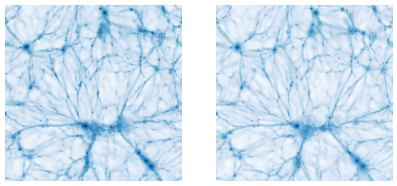

In [8]:
fig,axes = plt.subplots(1,2,figsize=(5,10))
axes[0].imshow(synth[0],cmap='Blues')
axes[0].axis('off')

axes[1].imshow(true[0],cmap='Blues')
axes[1].axis('off')

/tmp/ipykernel_616517/1906123051.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()


Text(0.5, 1.0, 'L25 Indistribution')

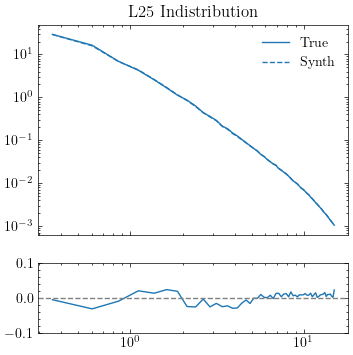

In [9]:
fig, axes = plt.subplots(2,1,figsize=(4,4),sharex=True,height_ratios=(3,1))

k1, pk1 = get_pk(true.astype(np.float32),box=25)
axes[0].loglog(k1,pk1,label=f'True',c=f'tab:blue')

k2, pk2 = get_pk(synth.astype(np.float32),box=25)
axes[0].loglog(k2,pk2,label=f'Synth',c=f'tab:blue',ls='--')

axes[1].plot(k1,pk2/pk1 - 1, c=f'tab:blue')

axes[0].legend()
axes[1].axhline(0,ls='--',c='grey')
axes[1].legend()
axes[1].set_ylim(-0.1,0.1)
axes[0].set_title('L25 Indistribution')

Text(0.5, 1.0, 'L50 Cutout Indistribution')

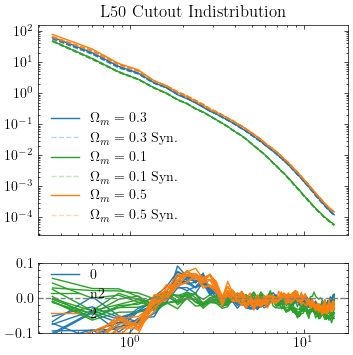

In [3]:
fig, axes = plt.subplots(2,1,figsize=(4,4),sharex=True,height_ratios=(3,1))


for i, colour, param in zip(['0','n2','2'],['Blue','Green','Orange'],['0.3','0.1','0.5']):
    cutout_true = np.load(f'/mnt/home/mliu1/ceph/exp/cutout_l25/true_gas_{i}.npy',mmap_mode='r')    
    k1, pk1 = get_pk(cutout_true.astype(np.float32),box=25)
    axes[0].loglog(k1,pk1,label=f'$\\Omega_m= {param}$',c=f'tab:{colour}')

    for j in range(10):

        cutout_synth = np.load(f'/mnt/home/mliu1/ceph/exp/cutout_l25/cutout_{i}_{j}.npy',mmap_mode='r')
        k2, pk2 = get_pk(cutout_synth.astype(np.float32),box=25)
        axes[0].loglog(k2,pk2,label=f'$\\Omega_m= {param}$ Syn.' if j==0 else None,alpha=0.3,c=f'tab:{colour}',ls='--')
        axes[1].plot(k1,pk2/pk1 - 1,label=f'{i}' if j==0 else None, c=f'tab:{colour}')

axes[0].legend()
axes[1].axhline(0,ls='--',c='grey')
axes[1].legend()
axes[1].set_ylim(-0.1,0.1)
axes[0].set_title('L50 Cutout Indistribution')

In [ ]:
fig, axes = plt.subplots(2,1,figsize=(4,4),sharex=True,height_ratios=(3,1))


for i, colour, param in zip(['0','n2','2'],['Blue','Green','Orange'],['0.3','0.1','0.5']):
    cutout_true = np.load(f'/mnt/home/mliu1/ceph/exp/cutout_l25/true_gas_{i}.npy',mmap_mode='r')    
    k1, pk1 = get_pk(cutout_true.astype(np.float32),box=25)
    axes[0].loglog(k1,pk1,label=f'$\\Omega_m= {param}$',c=f'tab:{colour}')

    for j in range(10):

        cutout_synth = np.load(f'/mnt/home/mliu1/ceph/exp/cutout_l25/cutout_{i}_{j}.npy',mmap_mode='r')
        k2, pk2 = get_pk(cutout_synth.astype(np.float32),box=25)
        axes[0].loglog(k2,pk2,label=f'$\\Omega_m= {param}$ Syn.' if j==0 else None,alpha=0.3,c=f'tab:{colour}',ls='--')
        axes[1].plot(k1,pk2/pk1 - 1,label=f'{i}' if j==0 else None, c=f'tab:{colour}')

axes[0].legend()
axes[1].axhline(0,ls='--',c='grey')
axes[1].legend()
axes[1].set_ylim(-0.1,0.1)
axes[0].set_title('L50 Cutout Indistribution')